# Lab 8: Maximum Margin Classification, SVMs, and the Kernel Trick

In this lab, you will build intuition and practical skill around Support Vector Machines (SVMs):
- Maximum margin classification and SVM formulation
- The Kernel Trick and non-linear decision boundaries
- Kernel optimization with cross-validation

You will use a **Kaggle dataset** and complete mini-challenges, class exercises, and a take-home assignment.

## Learning Outcomes
By the end of this lab, you should be able to:
1. Explain margin maximization and why support vectors matter.
2. Write the intuition behind the primal and dual SVM optimization problem.
3. Compare linear and kernelized SVMs on linearly separable and non-linear data.
4. Tune SVM hyperparameters (`C`, `kernel`, `gamma`, `degree`) using validation.
5. Interpret model behavior using support vectors, confusion matrix, and boundary plots.

## How to Work Through This Lab
For each activity, follow this loop:
1. **Predict** what will happen before running the code.
2. **Run** and observe outputs/plots.
3. **Explain** the result in your own words.
4. **Modify** one parameter and re-test your explanation.

This is deliberate practice: your understanding grows by testing hypotheses, not only reading theory.

In [ ]:
# If needed, uncomment and run once in notebook environments.
# %pip install -q kagglehub seaborn

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)

## Part A: Maximum Margin Classification (Geometry First)

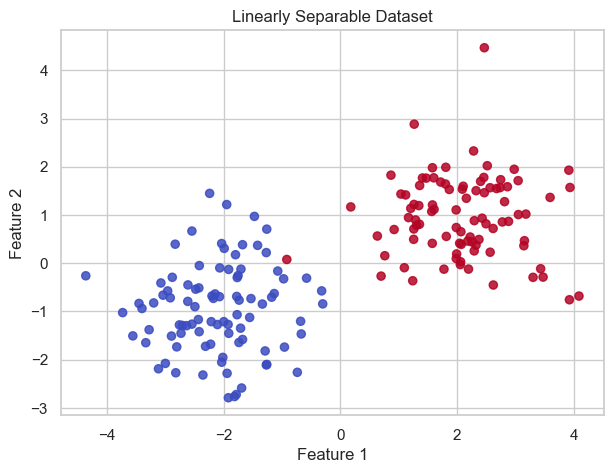

In [2]:
# Create a simple linearly separable dataset
X_lin, y_lin = make_blobs(
    n_samples=180,
    centers=[(-2, -1), (2, 1)],
    cluster_std=0.9,
    random_state=42
)

plt.figure(figsize=(7, 5))
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='coolwarm', s=35, alpha=0.85)
plt.title('Linearly Separable Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [3]:
def plot_svm_boundary(model, X, y, title='SVM decision boundary'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=35, edgecolor='k', alpha=0.9)

    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='black', linewidths=1.6, label='Support Vectors')
        plt.legend()

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

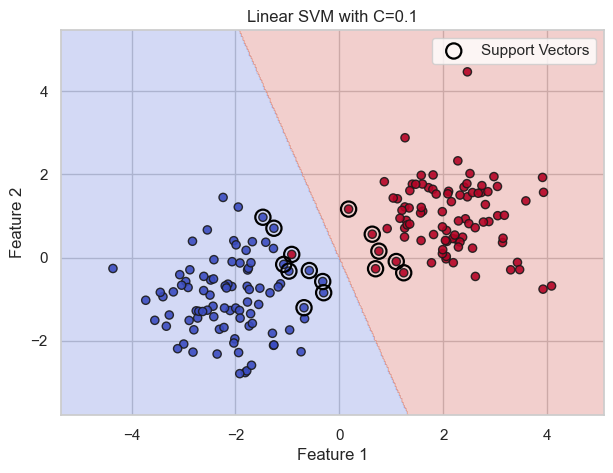

C=  0.1 | #SV= 15 | Approx margin width=2.1132
------------------------------------------------------------


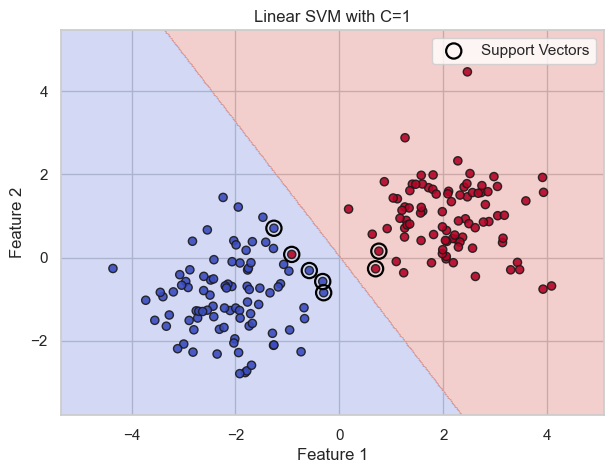

C=    1 | #SV=  7 | Approx margin width=1.4287
------------------------------------------------------------


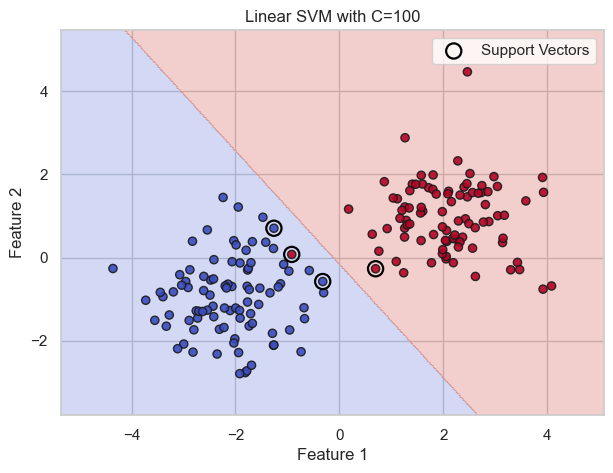

C=  100 | #SV=  4 | Approx margin width=1.0020
------------------------------------------------------------


In [4]:
# Compare hard-ish vs soft margin behavior through C
for C_val in [0.1, 1, 100]:
    svm_linear = SVC(kernel='linear', C=C_val)
    svm_linear.fit(X_lin, y_lin)
    plot_svm_boundary(svm_linear, X_lin, y_lin, title=f'Linear SVM with C={C_val}')

    if hasattr(svm_linear, 'coef_'):
        w = svm_linear.coef_[0]
        margin_width = 2 / np.linalg.norm(w)
        print(f'C={C_val:>5} | #SV={len(svm_linear.support_):>3} | Approx margin width={margin_width:.4f}')

    print('-' * 60)

### SVM Formulation (Compact)
For binary labels $y_i n -1,+1$ and input vectors $x_i$:

Hard-margin primal:
$$
in_{w,b} frac{1}{2}w^2 uad 	ext{s.t.}uad y_i(w^Tx_i+b) e 1 forall i
$$

Soft-margin primal:
$$
in_{w,b,i} frac{1}{2}w^2 + Cum_{i=1}^{n}i_i
uad 	ext{s.t.}uad y_i(w^Tx_i+b) e 1-i_i,i_ie0
$$

Dual (kernel-ready):
$$
ax_{lpha} um_i lpha_i - frac{1}{2}um_ium_j lpha_ilpha_jy_iy_jK(x_i,x_j)
$$
with constraints $0elpha_ie C$ and $um_i lpha_i y_i = 0$.

Only points with non-zero $lpha_i$ become **support vectors**.

### Fun Class Exercise 1: Margin Detective (10 minutes)
1. In pairs, pick two values of `C` from: `0.01, 0.1, 1, 10, 100`.
2. Predict which one gives wider margin and more support vectors.
3. Run, compare, and explain why.
4. Share one counter-intuitive observation with the class.

Write your findings in one short paragraph below.

In [ ]:
# Student notes (edit this cell):
student_reflection_margin = ""
print('Reflection saved length:', len(student_reflection_margin))

## Part B: Real Data Task (Kaggle Dataset)
We will use Kaggle dataset: **Breast Cancer Wisconsin (Diagnostic)**  
Dataset ID: `uciml/breast-cancer-wisconsin-data`

Target column: `diagnosis` (`M` malignant, `B` benign).

If Kaggle credentials are unavailable, a fallback to `sklearn` breast cancer dataset is included so the lab remains runnable.

In [5]:
# Kaggle download with graceful fallback
df = None
try:
    import kagglehub
    path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')
    csv_path = os.path.join(path, 'data.csv')
    df = pd.read_csv(csv_path)
    source_name = 'kaggle'
except Exception as e:
    print('Kaggle load unavailable:', str(e)[:180])
    bc = load_breast_cancer(as_frame=True)
    df = bc.frame.copy()
    df['diagnosis'] = np.where(df['target'] == 1, 'B', 'M')
    df.drop(columns=['target'], inplace=True)
    source_name = 'sklearn_fallback'

print('Data source:', source_name)
print('Shape:', df.shape)
df.head()

Kaggle load unavailable: No module named 'kagglehub'
Data source: sklearn_fallback
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [6]:
# Basic cleaning and train-ready matrix
df_model = df.copy()

for col in ['id', 'Unnamed: 32']:
    if col in df_model.columns:
        df_model.drop(columns=[col], inplace=True)

if 'diagnosis' not in df_model.columns:
    raise ValueError('Expected diagnosis column not found.')

y = df_model['diagnosis'].map({'B': 0, 'M': 1}).astype(int)
X = df_model.drop(columns=['diagnosis'])

print('Features:', X.shape[1])
print('Class distribution:')
print(y.value_counts(normalize=True).rename({0: 'Benign(0)', 1: 'Malignant(1)'}))

Features: 30
Class distribution:
diagnosis
Benign(0)       0.627417
Malignant(1)    0.372583
Name: proportion, dtype: float64


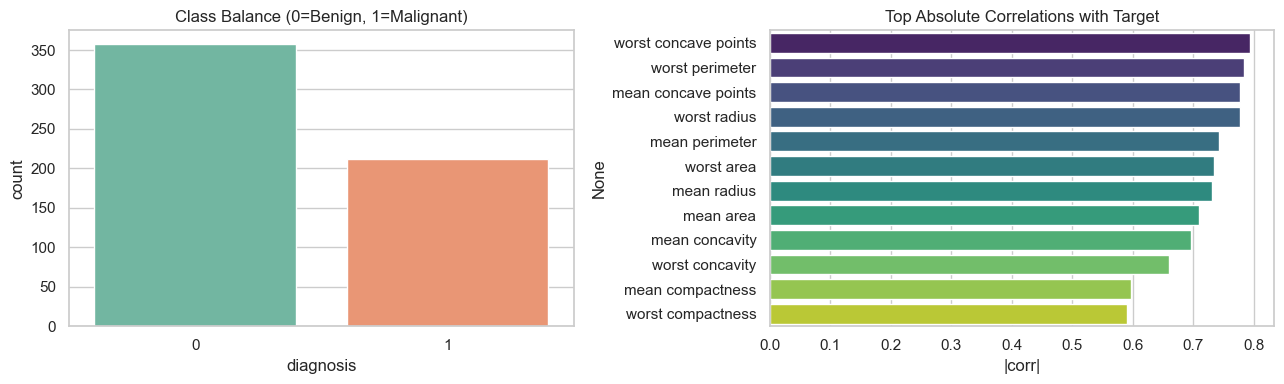

In [7]:
# Quick exploratory view
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x=y, ax=axes[0], palette='Set2')
axes[0].set_title('Class Balance (0=Benign, 1=Malignant)')

top_corr = X.assign(target=y).corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False).head(12)
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top Absolute Correlations with Target')
axes[1].set_xlabel('|corr|')

plt.tight_layout()
plt.show()

In [8]:
# Baseline split and baseline linear SVM
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42))
])

linear_pipe.fit(X_train, y_train)
pred = linear_pipe.predict(X_test)

print('Linear SVM Accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, target_names=['Benign', 'Malignant']))

Linear SVM Accuracy: 0.9649
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



### Fun Class Exercise 2: Clinical Trade-off Game (12 minutes)
Scenario: This model flags malignant tumors.

1. As a team, decide what matters more: precision or recall for malignant class.
2. Justify your choice in a healthcare context.
3. Propose one model tuning move that could improve your chosen metric.

Capture your team decision below.

In [ ]:
team_decision = {
    'priority_metric': '',
    'justification': '',
    'tuning_strategy': ''
}
team_decision

## Part C: Kernel Trick and Non-linear Predictions

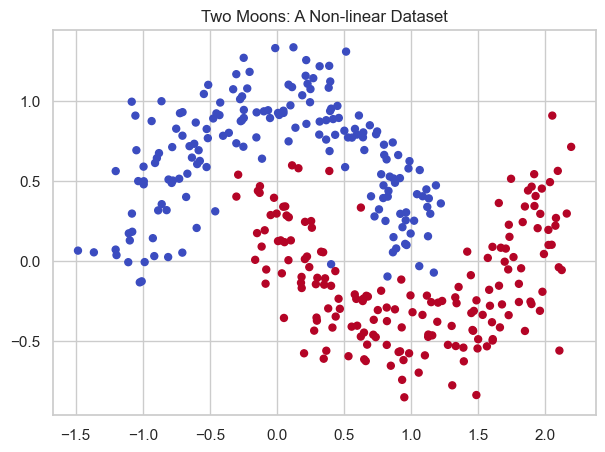

In [9]:
# Non-linear toy dataset
X_moon, y_moon = make_moons(n_samples=350, noise=0.18, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', s=25)
plt.title('Two Moons: A Non-linear Dataset')
plt.show()

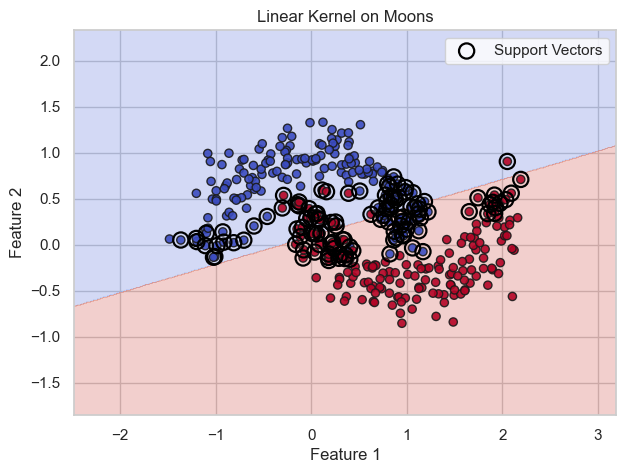

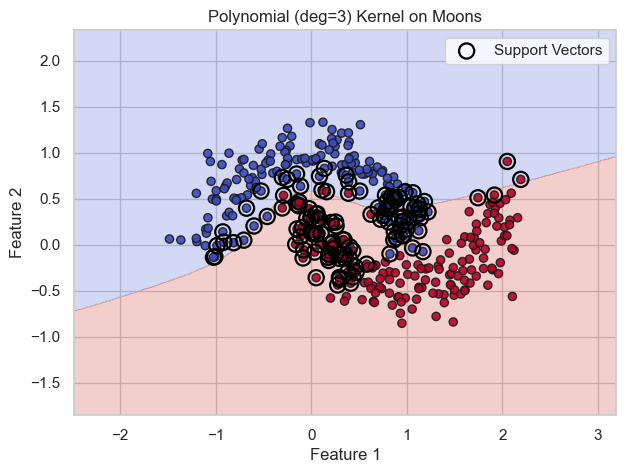

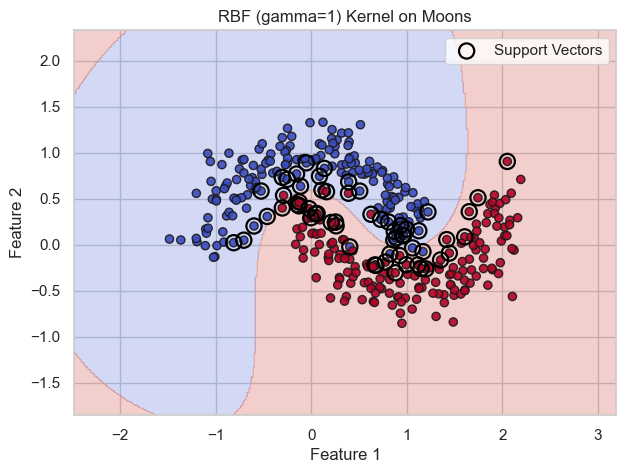

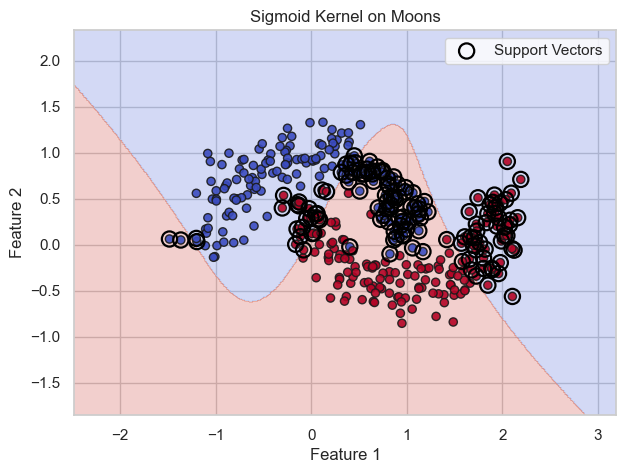

In [10]:
models = {
    'Linear': SVC(kernel='linear', C=1),
    'Polynomial (deg=3)': SVC(kernel='poly', degree=3, C=1, gamma='scale'),
    'RBF (gamma=1)': SVC(kernel='rbf', C=1, gamma=1),
    'Sigmoid': SVC(kernel='sigmoid', C=1, gamma='scale')
}

for name, clf in models.items():
    clf.fit(X_moon, y_moon)
    plot_svm_boundary(clf, X_moon, y_moon, title=f'{name} Kernel on Moons')

### Kernel Intuition
Kernels let SVM compute similarity in an implicit high-dimensional feature space:
- Linear: $K(x,z)=x^Tz$
- Polynomial: $K(x,z)=(amma x^Tz+r)^d$
- RBF: $K(x,z)=xp(-ammax-z^2)$

You avoid explicitly computing transformed features but still learn non-linear boundaries.

### Fun Class Exercise 3: Hyperparameter Karaoke (10 minutes)
Each group gets one parameter card: `C`, `gamma`, or `degree`.

1. Predict what happens when your parameter is very low vs very high.
2. Demonstrate with one quick run.
3. Present your 'parameter story' in under 60 seconds.

In [ ]:
# Sandbox: edit values and rerun
C_sandbox = 1
gamma_sandbox = 1
degree_sandbox = 3

sandbox_model = SVC(kernel='poly', C=C_sandbox, gamma=gamma_sandbox, degree=degree_sandbox)
sandbox_model.fit(X_moon, y_moon)
plot_svm_boundary(sandbox_model, X_moon, y_moon, title=f'Sandbox poly SVM | C={C_sandbox}, gamma={gamma_sandbox}, degree={degree_sandbox}')

## Part D: Kernel Optimization on Kaggle Data

In [11]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10, 100]},
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.1, 1]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3, 4], 'svm__gamma': ['scale', 0.01, 0.1]}
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)
print('Best Params:', grid.best_params_)
print('Best CV F1:', round(grid.best_score_, 4))

Best Params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1: 0.9647


In [12]:
cv_results = pd.DataFrame(grid.cv_results_)
summary_cols = ['mean_test_score', 'std_test_score', 'param_svm__kernel', 'param_svm__C', 'param_svm__gamma', 'param_svm__degree']
summary = cv_results[summary_cols].sort_values('mean_test_score', ascending=False).head(12)
summary

,mean_test_score,std_test_score,param_svm__kernel,param_svm__C,param_svm__gamma,param_svm__degree
12,0.964742,0.023053,rbf,10.0,scale,NaN
8,0.964147,0.017966,rbf,1.0,scale,NaN
13,0.963888,0.018084,rbf,10.0,0.01,NaN
17,0.959045,0.039730,rbf,100.0,0.01,NaN
0,0.957549,0.022321,linear,0.1,NaN,NaN
2,0.954849,0.025637,linear,10.0,NaN,NaN
1,0.951623,0.024711,linear,1.0,NaN,NaN
9,0.950320,0.032586,rbf,1.0,0.01,NaN
16,0.947621,0.032042,rbf,100.0,scale,NaN
3,0.947399,0.025031,linear,100.0,NaN,NaN


Test Accuracy: 0.9737
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



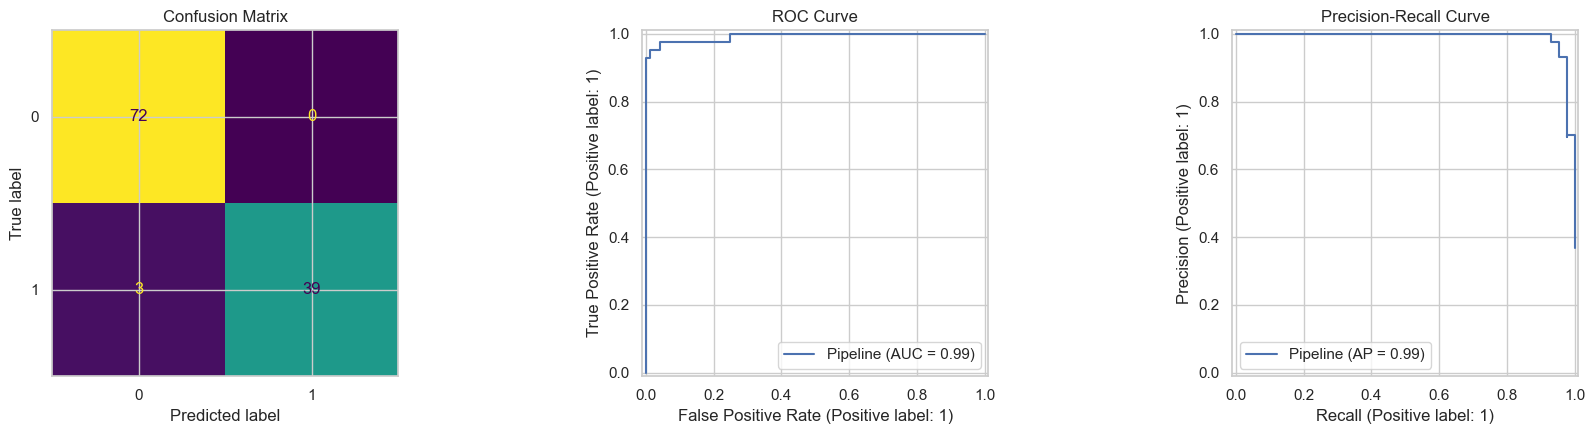

In [13]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

print('Test Accuracy:', round(accuracy_score(y_test, best_pred), 4))
print(classification_report(y_test, best_pred, target_names=['Benign', 'Malignant']))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

### Reflection Prompt
Answer in 3-5 lines:
1. Which kernel won and why might it fit this dataset?
2. Did performance gains justify extra tuning complexity?
3. In production, what monitoring signal would you track first?

In [ ]:
reflection = ""
print('Reflection chars:', len(reflection))

## Assignment (Individual)
### Task A: Maximum Margin in Action
- Using the synthetic dataset, compare `C=0.01`, `C=1`, `C=100`.
- Report: margin width, number of support vectors, and test accuracy on a held-out split.
- Explain the bias-variance trade-off observed.

### Task B: Kernel Selection Report
Using the Kaggle dataset:
- Train and tune `linear`, `rbf`, and `poly` SVMs.
- Compare by F1 score, recall(malignant), and inference time.
- Recommend one model for deployment with justification.

### Task C: What-if Scenario
Suppose malignant class prevalence drops from 37% to 10%.
- What changes in evaluation strategy?
- Would you alter `class_weight`, thresholding, or both? Why?

### Deliverables
1. Notebook with code, outputs, and explanations.
2. One-page summary (PDF/Markdown) with final recommendation.
3. Short appendix: hyperparameter table and confusion matrix.

## Wrap-up
You have completed an end-to-end SVM lab from theory to optimization on real data.

If you can explain when and why to choose a kernelized SVM over a linear model, and how `C` and `gamma` shape generalization, you have achieved the core goals of Week 8.